# Assignment 3: Time Series Prediction of Sepsis

Authors:  
Max Masuch  
Ismail Mohammed

## Imports

In [200]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import read_csv
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Input
from keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score

## Load data

The dataset is divided into Partition A, B, C and D. Partition A and B are used for training the model, C is used for validation, and D is used for the final testing. Each dataset is stored as a “.tsv” file and loaded using pandas.read_csv().
The dataset contains several physiological measurements such as heart rate, temperature, respiratory rate and other laboratory values.
In addition to the measurements, the dataset also includes important variables such as id, which identifies each patient, timestep, which represents the time of the measurement, and sepsis and severity, which describe the patient’s condition.

In [201]:
df_a = pd.read_csv('raw_data/sepsisexp_timeseries_partition-A.tsv', sep='\t')

df_b = pd.read_csv('raw_data/sepsisexp_timeseries_partition-B.tsv', sep='\t')

df_c = pd.read_csv('raw_data/sepsisexp_timeseries_partition-C.tsv', sep='\t')

df_d = pd.read_csv('raw_data/sepsisexp_timeseries_partition-D.tsv', sep='\t')

print(df_a.head())

      id  sepsis  severity  timestep  respiratory_minute_volume  heart_rate  \
0  12292       0       0.0       0.0                   0.190898    0.424464   
1  12292       0       0.0       0.5                   0.157654    0.667394   
2  12292       0       0.0       1.0                   0.024678    0.618808   
3  12292       0       0.0       1.5                  -0.208030    0.278706   
4  12292       0       0.0       2.0                  -0.108298   -0.352912   

   leukocytes  temperature  partial_co2  respiratory_rate  ...   calcium  \
0    0.301015    -0.168117    -0.275272          1.879692  ...  1.019083   
1    0.301015    -0.168117    -0.275272          1.708485  ...  1.019083   
2    0.301015    -0.732387     1.003408          2.050899  ... -0.868157   
3    0.301015    -0.732387     1.003408          1.366071  ... -0.868157   
4    0.301015    -0.732387     1.094023          1.537278  ... -0.868157   

   potassium  mixed_venous_oxygen_saturation  urine_output  net bala

In this step we merge the data partitions, A and B for training, we use C for validation and D for testing. 

In [202]:
train_df = pd.concat([df_a, df_b], axis=0).reset_index(drop=True)
val_df = df_c.reset_index(drop=True)
test_df = df_d.reset_index(drop=True)

Here we chose to remove the columns Id, Sepsis, Severity and Timestep. We did that to make sure that the model learns genuine patterns and doesn't "cheat" or focus on unnecassary data. Id was removed to prevent the model from memorizing specific patients. Sepsis and Severity were removed since they were the answer and would make the model just use those two values to predict. Timestep was removed to force the model to focus on clinical trends rather than just the duration of the hospital stay.

In [203]:
excluded = ['id', 'sepsis', 'severity', 'timestep']
features = [col for col in train_df.columns if col not in excluded]

To change this problem from a standard classification task, like the previous assignment, into a predictive task, we create time shifted target variables for the model. By applying shift() to the sepsis label we align the future outcomes with the current medical data.

In [204]:
def add_targets(df):
    df['target_2h'] = df.groupby('id')['sepsis'].shift(-4)
    df['target_4h'] = df.groupby('id')['sepsis'].shift(-8)
    df['target_6h'] = df.groupby('id')['sepsis'].shift(-12)
    return df

In [205]:
df_train = add_targets(train_df)
df_val = add_targets(val_df)
df_test = add_targets(test_df)

However when we apply shift() to create our targets, the last n rows for every patient become Null because there is no "future" data available to pull from.

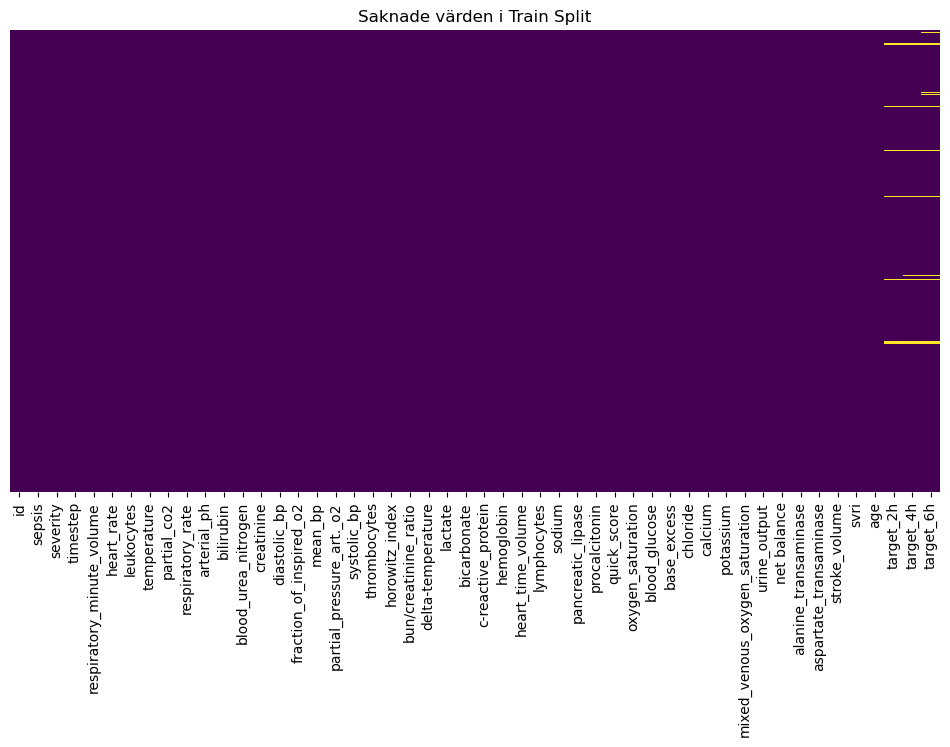

In [206]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Saknade värden i Train Split')
plt.show()

To fix that we use Forward Fill or ffill(). We do that to ensure that every time step in our sequences has a valid value, allowing the model to utilize as much of the patient's history as possible without crashing.

In [ ]:
df_train = df_train.ffill
df_test = df_test.ffill
df_val.ffill

,id,sepsis,severity,timestep,respiratory_minute_volume,heart_rate,leukocytes,temperature,partial_co2,respiratory_rate,...,urine_output,net balance,alanine_transaminase,aspartate_transaminase,stroke_volume,svri,age,target_2h,target_4h,target_6h
0,12290,0,0.0,0.0,-0.530498,-1.081702,-0.706908,-0.168117,-0.275272,-1.373239,...,-0.511002,-0.333854,-0.284669,-0.322856,0.317126,0.061715,-1.193030,0.0,0.0,0.0
1,12290,0,0.0,0.5,-0.530498,-1.373218,-0.706908,-0.506679,-0.275272,-1.373239,...,-0.511002,-0.333854,-0.284669,-0.322856,0.317126,0.061715,-1.193030,0.0,0.0,0.0
2,12290,0,0.0,1.0,-0.530498,-1.421804,-0.706908,-0.506679,-0.275272,-1.373239,...,-0.511002,-0.333854,-0.284669,-0.322856,0.317126,0.061715,-1.193030,0.0,0.0,0.0
3,12290,0,0.0,1.5,-0.530498,-1.373218,-0.706908,-0.506679,-0.275272,-1.373239,...,-0.511002,-0.333854,-0.284669,-0.322856,0.317126,0.061715,-1.193030,0.0,0.0,0.0
4,12290,0,0.0,2.0,-0.530498,-1.373218,-0.706908,-0.506679,-0.275272,-1.373239,...,-0.511002,-0.333854,-0.284669,-0.322856,0.317126,0.061715,-1.193030,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156214,11773,1,2.0,109.0,-0.773180,-0.693014,0.069104,0.283300,-0.164520,-1.373239,...,-0.351446,-0.353863,-0.388995,-0.449874,1.484949,-1.014813,-0.671671,1.0,1.0,1.0
156215,11773,1,2.0,109.5,-0.640204,-0.644428,0.069104,0.396154,-0.164520,-1.202032,...,-0.351446,-0.353863,-0.388995,-0.449874,1.484949,-1.014813,-0.671671,1.0,1.0,1.0
156216,11773,1,2.0,110.0,-0.872912,-0.595842,0.069104,0.509008,-0.164520,-1.202032,...,-0.710447,-0.351738,-0.388995,-0.449874,1.484949,-1.014813,-0.671671,1.0,1.0,1.0
156217,11773,1,2.0,110.5,-0.573715,-0.450084,0.069104,0.509008,-0.164520,-1.030825,...,-0.710447,-0.351738,-0.388995,-0.449874,1.484949,-1.014813,-0.671671,1.0,1.0,1.0


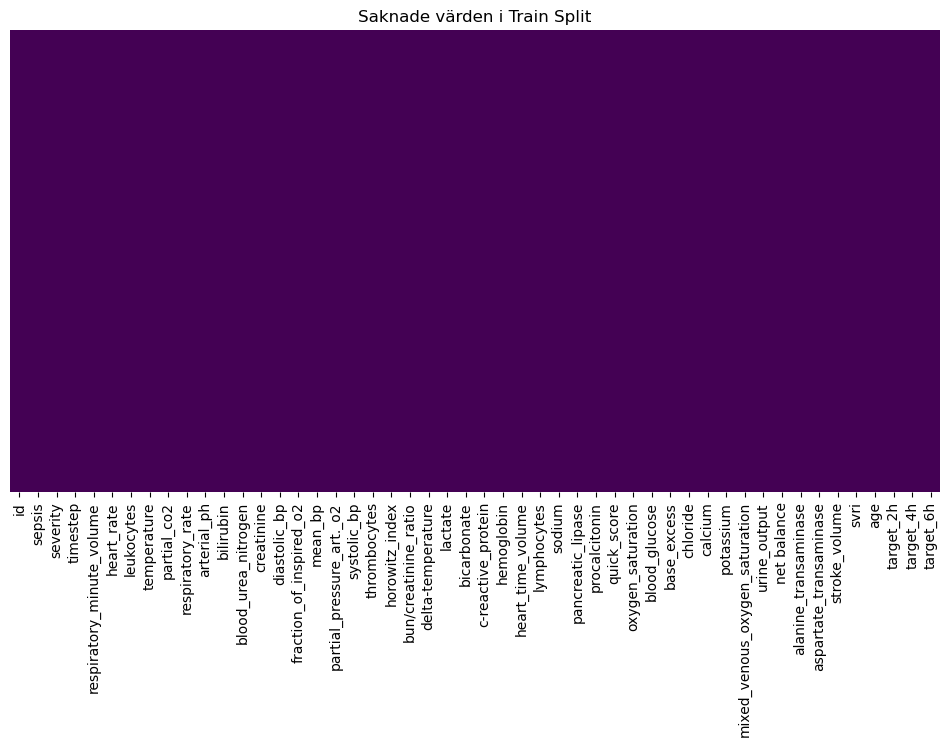

In [208]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Saknade värden i Train Split')
plt.show()

LSTM models require a three dimensional input shape: (samples, time_steps, features). With the create_sequences function we prepare the data into a format that the LSTM model can process. What the functions does is it first processes each patient individually. It then creates a sliding window that captures a specific block of history of a set length (window_size) and pairs it with the single outcome immediately following that window. It then reshapes the data into the structure required by the LSTM model.

In [209]:
def create_sequences(df, feature_cols, target_col, window_size):
    X, y = [], []
    for _, group in df.groupby('id'):
        if len(group) <= window_size:
            continue
        
        data = group[feature_cols].values
        target = group[target_col].values
        
        for i in range(len(group) - window_size):
            X.append(data[i : i + window_size])
            y.append(target[i + window_size])
            
    return np.array(X), np.array(y)

In this step we generate the final datasets for our three predictions. We chose to use larger window sizes as the predictions also grow larger. For the 2 h prediction we chose a window size of 12, which would be 6 hours of information in the data. Then for the larger predictions we knew that the model would need more information to be abe to distinguish between temporary fluctuations and an actual developing septic infection. We tried different values for the different predictions and the numbers we landed at (12 ,24 and 36) gave us the best results. 

In [210]:
X_train_2h, y_train_2h = create_sequences(df_train, features, 'target_2h', 12)
X_val_2h, y_val_2h = create_sequences(df_val, features, 'target_2h', 12)
X_test_2h, y_test_2h = create_sequences(df_test, features, 'target_2h', 12)

X_train_4h, y_train_4h = create_sequences(df_train, features, 'target_4h', 24)
X_val_4h, y_val_4h = create_sequences(df_val, features, 'target_4h', 24)
X_test_4h, y_test_4h = create_sequences(df_test, features, 'target_4h', 24)

X_train_6h, y_train_6h = create_sequences(df_train, features, 'target_6h', 36)
X_val_6h, y_val_6h = create_sequences(df_val, features, 'target_6h', 36)
X_test_6h, y_test_6h = create_sequences(df_test, features, 'target_6h', 36)

During the start of our training, we encountered a lot of overfitting. The model would reach an almost perfect AUC on the training set while the validation loss skyrocketed after only 1 or 2 epochs. To try to solve this, we tested several different configurations.
We experimented with stacking two LSTM layers with various amount of nodes. From 256 down to 32 nodes. While this increased the model's capacity, it also made it more prone to memorizing noise in the training data. We ultimately settled on a single 64 node layer for better generalization. We also added a Dropout layer to randomly mute neurons during training. We tested values from 0 up till 0.5. This forces the network to learn redundant representations of the data and prevents it from relying too heavily on any single feature.
Standard learning rates  caused the model to converge too aggressively. By dropping the learning rate significantly, we allowed the model to take "smaller steps," leading to a more stable and reliable training curve.
Following the recommendations in Schamoni et al. (2022), we used a smaller batch size. This introduces a slight amount of noise during the weight updates, which somehow helped the model generalize better to new patients.

To make that the model did not overfit to much we also added Early Stopping with a patience of 3. This would then automatically stop the training when the val_loss would stop improving and restore the model from the point where the model performed best on the validation set.

In [211]:
def train_model(X_train, y_train, X_val, y_val):
    
    model = Sequential()

    model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

    model.add(LSTM(64, return_sequences=False))

    model.add(Dropout(0.2))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)

    model.compile(optimizer=optimizer, 
        loss='binary_crossentropy', 
        metrics=['accuracy', 'auc'])
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3, 
        restore_best_weights=True)


    model.fit(
        X_train, y_train, 
        validation_data=(X_val, y_val), 
        epochs=25, batch_size=20, 
        callbacks=[early_stop], verbose=1)
    
    return model

In [212]:
print('2h Model')
model_2h = train_model(X_train_2h, y_train_2h, X_val_2h, y_val_2h)

2h Model
Epoch 1/25
15061/15061 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.7645 - auc: 0.8381 - loss: 0.4867 - val_accuracy: 0.7141 - val_auc: 0.7532 - val_loss: 0.5997
Epoch 2/25
15061/15061 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.8427 - auc: 0.9179 - loss: 0.3561 - val_accuracy: 0.7009 - val_auc: 0.7495 - val_loss: 0.6609
Epoch 3/25
15061/15061 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.8825 - auc: 0.9502 - loss: 0.2792 - val_accuracy: 0.6957 - val_auc: 0.7413 - val_loss: 0.7457
Epoch 4/25
15061/15061 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.9046 - auc: 0.9656 - loss: 0.2321 - val_accuracy: 0.6901 - val_auc: 0.7386 - val_loss: 0.8284


In [213]:
print('4h Model')
model_4h = train_model(X_train_4h, y_train_4h, X_val_4h, y_val_4h)

4h Model
Epoch 1/25
14678/14678 ━━━━━━━━━━━━━━━━━━━━ 68s 5ms/step - accuracy: 0.7591 - auc: 0.8332 - loss: 0.4877 - val_accuracy: 0.7236 - val_auc: 0.7574 - val_loss: 0.5886
Epoch 2/25
14678/14678 ━━━━━━━━━━━━━━━━━━━━ 57s 4ms/step - accuracy: 0.8602 - auc: 0.9317 - loss: 0.3246 - val_accuracy: 0.7035 - val_auc: 0.7519 - val_loss: 0.6750
Epoch 3/25
14678/14678 ━━━━━━━━━━━━━━━━━━━━ 57s 4ms/step - accuracy: 0.9000 - auc: 0.9629 - loss: 0.2407 - val_accuracy: 0.6972 - val_auc: 0.7413 - val_loss: 0.7771
Epoch 4/25
14678/14678 ━━━━━━━━━━━━━━━━━━━━ 56s 4ms/step - accuracy: 0.9243 - auc: 0.9769 - loss: 0.1898 - val_accuracy: 0.6927 - val_auc: 0.7311 - val_loss: 0.8847


In [214]:
print('6h Model')
model_6h = train_model(X_train_6h, y_train_6h, X_val_6h, y_val_6h)

6h Model
Epoch 1/25
14298/14298 ━━━━━━━━━━━━━━━━━━━━ 72s 5ms/step - accuracy: 0.7696 - auc: 0.8392 - loss: 0.4788 - val_accuracy: 0.7201 - val_auc: 0.7405 - val_loss: 0.6180
Epoch 2/25
14298/14298 ━━━━━━━━━━━━━━━━━━━━ 70s 5ms/step - accuracy: 0.8739 - auc: 0.9372 - loss: 0.3093 - val_accuracy: 0.7117 - val_auc: 0.7346 - val_loss: 0.7249
Epoch 3/25
14298/14298 ━━━━━━━━━━━━━━━━━━━━ 71s 5ms/step - accuracy: 0.9137 - auc: 0.9687 - loss: 0.2197 - val_accuracy: 0.6975 - val_auc: 0.7241 - val_loss: 0.8561
Epoch 4/25
14298/14298 ━━━━━━━━━━━━━━━━━━━━ 70s 5ms/step - accuracy: 0.9367 - auc: 0.9819 - loss: 0.1660 - val_accuracy: 0.6926 - val_auc: 0.7166 - val_loss: 0.9936


In this step we test our models on Partition D. This data was completely isolated during the training and validation phases, serving as our final simulation.
We apply the same variable lookback windows as previously to ensure consistency. By evaluating the models on this unseen data, we can verify that our techniques (Dropout and Low Learning Rate) successfully prevented the model from simply memorizing the training data and instead allowed it to learn generalizable clinical patterns.

In [215]:
X_test_2h, y_test_2h = create_sequences(df_test, features, 'target_2h', 12)
X_test_4h, y_test_4h = create_sequences(df_test, features, 'target_4h', 24)
X_test_6h, y_test_6h = create_sequences(df_test, features, 'target_6h', 36)

The 2 hour prediction achieved an accuracy of 0.73 and AUC 0.79. 4 hour achieved accuracy 0.72 and AUC 0.78 and 6 hour accuracy 0.74, AUC 0.79. This indicates that the model was able to learn patterns.

Interestingly, the performance remains stable even as the prediction horizon increases to 6 hours. This suggests that our strategy of increasing the lookback window for longer-range predictions was effective by providing the model with 18 hours of history for the 6h target, we gave it enough context to maintain high predictive power.

In [216]:
results_2h = model_2h.evaluate(X_test_2h, y_test_2h, verbose=1)
results_4h = model_4h.evaluate(X_test_4h, y_test_4h, verbose=1)
results_6h = model_6h.evaluate(X_test_6h, y_test_6h, verbose=1)

4178/4178 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7288 - auc: 0.7902 - loss: 0.5451
4059/4059 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7201 - auc: 0.7815 - loss: 0.5549
3940/3940 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7364 - auc: 0.7914 - loss: 0.5423


To  identify a minimal set of features, we perform a "Drop-in-AUC" analysis. This mirrors the methodology used in our previous ECG assignment. By systematically zeroing out one feature at a time and measuring the resulting decrease in the model's AUC, we can identify which values and vital signs carry the most power for predicting sepsis.

In [217]:
def plot_feature_importance(model, X_test, y_test, feature_names):
    
    y_pred_base = model.predict(X_test, verbose=0)
    base_auc = roc_auc_score(y_test, y_pred_base)
    print(f"\nBase AUC : {base_auc:.4f}")

    importance_scores = []

    for i in range(len(feature_names)):
        X_test_new = np.copy(X_test)
        
        X_test_new[:, :, i] = 0
        
        y_pred_new = model.predict(X_test_new, verbose=0)
        new_auc = roc_auc_score(y_test, y_pred_new)
        
        drop_in_auc = base_auc - new_auc
        importance_scores.append(drop_in_auc)

    plt.figure(figsize=(10, 12))
    
    sorted_idx = np.argsort(importance_scores)
    pos = np.arange(sorted_idx.shape[0]) + .5

    plt.barh(pos, np.array(importance_scores)[sorted_idx], align='center', color='skyblue', edgecolor='black')
    plt.yticks(pos, np.array(feature_names)[sorted_idx])
    plt.title(f'Feature Importance (Drop in AUC)')
    plt.xlabel('Drop in AUC when feature is removed')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()



Base AUC : 0.7903


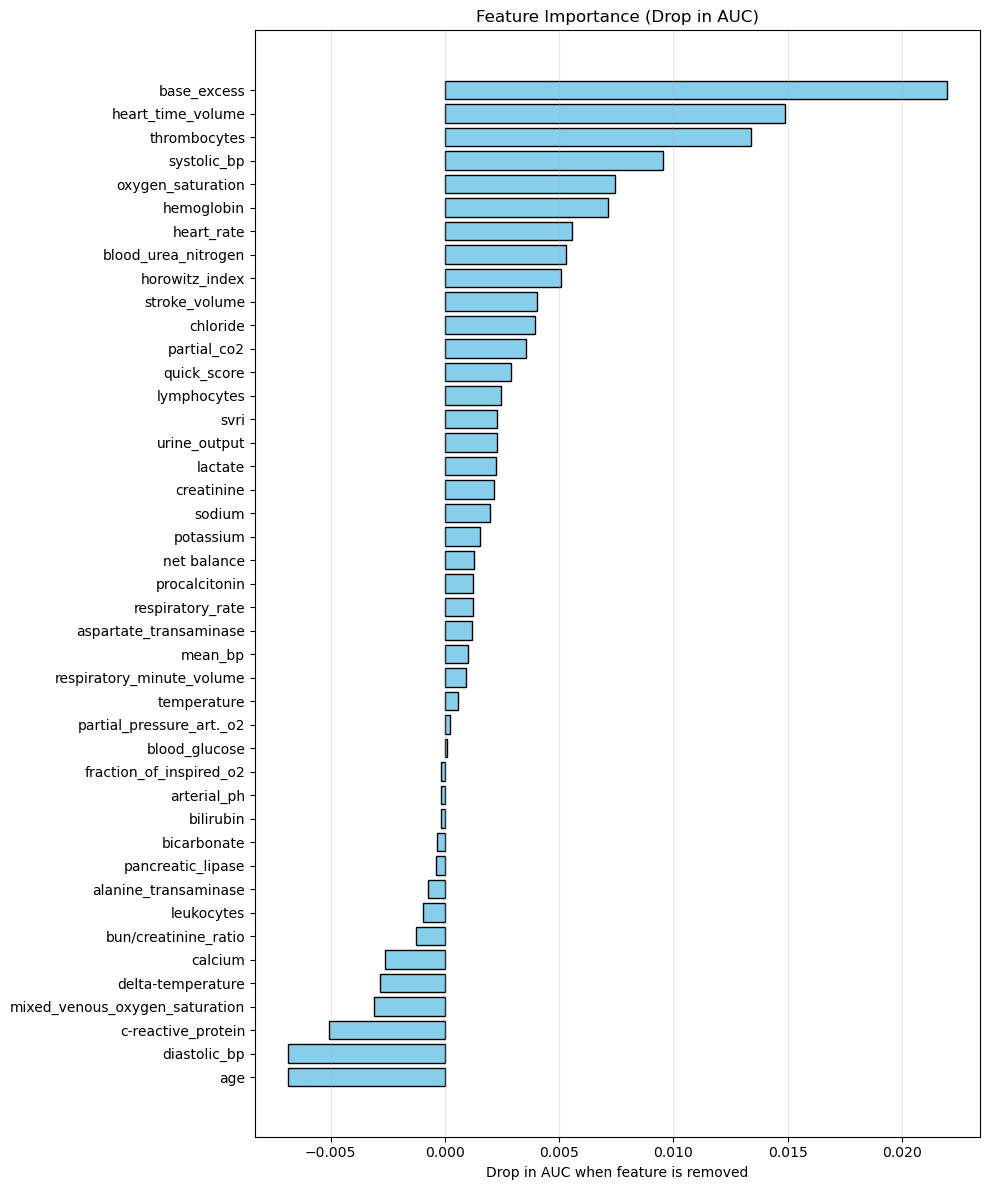

In [218]:
plot_feature_importance(model_2h, X_test_2h, y_test_2h, features)


Base AUC : 0.7814


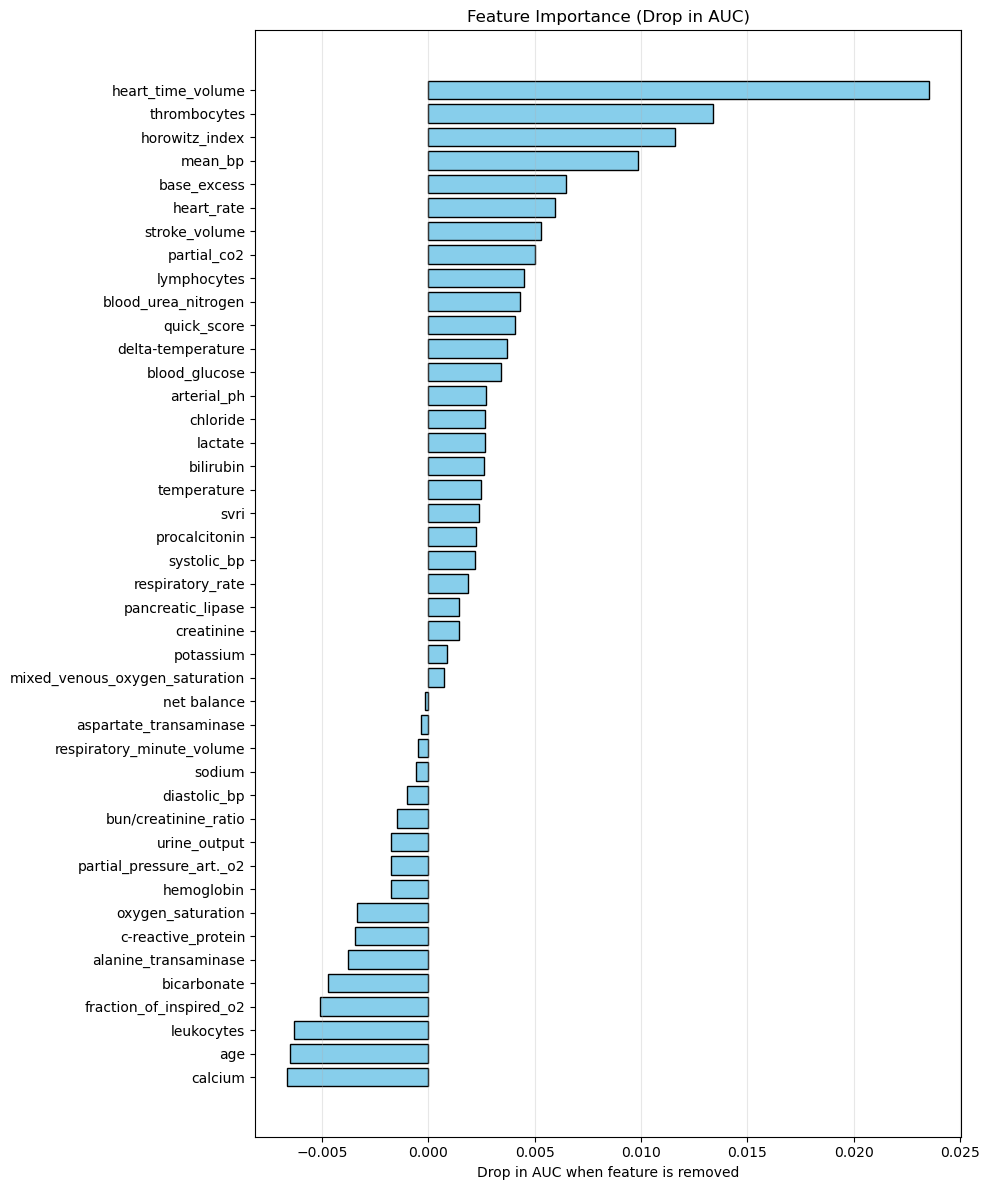

In [219]:
plot_feature_importance(model_4h, X_test_4h, y_test_4h, features)


Base AUC : 0.7914


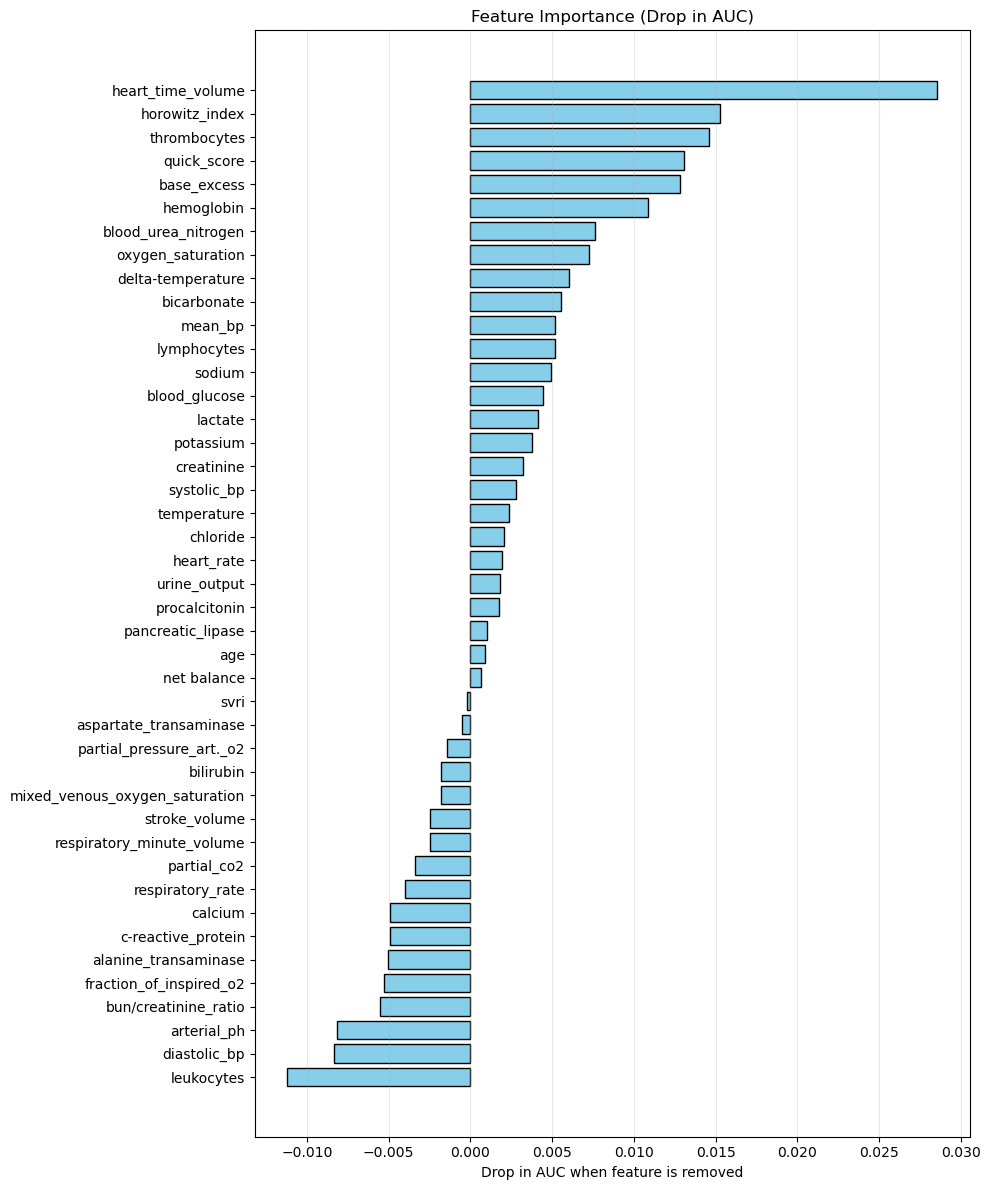

In [220]:
plot_feature_importance(model_6h, X_test_6h, y_test_6h, features)

By looking at the two larger predictions (4h and 6h) we see that their three top features are the same. They were Heart Time Volume, Horowitz Index and Thrombocytes. 

### Conclusion

Overall the results shows that time series clinical data can be used to detect early signs of sepsis, however predicting is still a very difficult task. 

In [221]:
model_2h.save('models/LSTM_2h_79_2603131650.keras')
model_4h.save('models/LSTM_4h_78_2603131650.keras')
model_6h.save('models/LSTM_6h_79_2603131650.keras')